In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_excel('/content/online_course_recommendation_v2.xlsx')
df.head()

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5


In [3]:
df['course_name'] = df['course_name'].str.strip()
df['instructor'] = df['instructor'].str.strip()
df['course_key'] = df['course_name'] + "_" + df['instructor']
df['course_id'] = df.groupby('course_key').ngroup()
df['topic'] = df['course_name'].str.split().str[0].str.lower()
difficulty_order = {
    "Beginner": 1,
    "Intermediate": 2,
    "Advanced": 3}

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

,0
user_id,0
course_id,0
course_name,0
instructor,0
course_duration_hours,0
certification_offered,0
difficulty_level,0
rating,0
enrollment_numbers,0
course_price,0


In [6]:
df.dtypes

,0
user_id,int64
course_id,int64
course_name,object
instructor,object
course_duration_hours,float64
certification_offered,object
difficulty_level,object
rating,float64
enrollment_numbers,int64
course_price,float64


In [7]:
df.columns

Index(['user_id', 'course_id', 'course_name', 'instructor',
       'course_duration_hours', 'certification_offered', 'difficulty_level',
       'rating', 'enrollment_numbers', 'course_price', 'feedback_score',
       'study_material_available', 'time_spent_hours',
       'previous_courses_taken', 'course_key', 'topic'],
      dtype='object')

In [8]:
df.columns

Index(['user_id', 'course_id', 'course_name', 'instructor',
       'course_duration_hours', 'certification_offered', 'difficulty_level',
       'rating', 'enrollment_numbers', 'course_price', 'feedback_score',
       'study_material_available', 'time_spent_hours',
       'previous_courses_taken', 'course_key', 'topic'],
      dtype='object')

In [9]:
df.shape

(100000, 16)

In [10]:
df.describe()

,user_id,course_id,course_duration_hours,rating,enrollment_numbers,course_price,feedback_score,time_spent_hours,previous_courses_taken
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,24935.663570,199.384900,52.38354,3.959859,25052.822850,261.073369,0.746865,20.691054,4.992670
std,14406.960108,115.520785,27.42347,0.729958,14388.188356,139.013758,0.143683,13.669148,2.237259
min,1.000000,0.000000,5.00000,1.000000,50.000000,20.000000,0.092000,1.000000,0.000000
25%,12487.750000,99.000000,28.60000,3.500000,12583.750000,140.100000,0.649000,9.900000,3.000000
50%,24793.500000,199.000000,52.40000,4.000000,25057.500000,262.310000,0.750000,19.920000,5.000000
75%,37382.250000,299.000000,76.10000,4.500000,37522.000000,381.702500,0.851000,30.080000,6.000000
max,49999.000000,399.000000,100.00000,5.000000,49999.000000,500.000000,1.000000,84.150000,19.000000


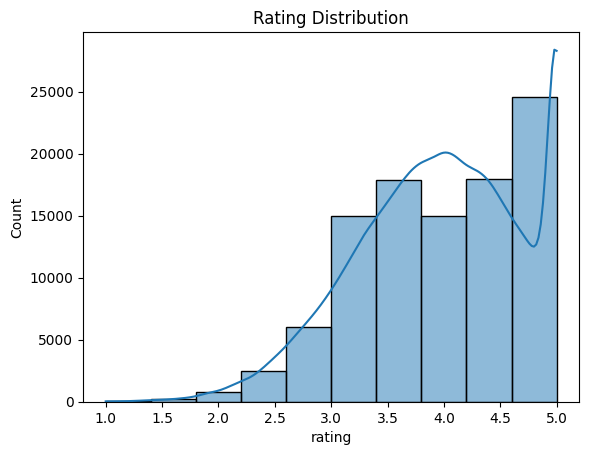

In [11]:
plt.figure()
sns.histplot(df['rating'], bins=10, kde=True)
plt.title("Rating Distribution")
plt.show()

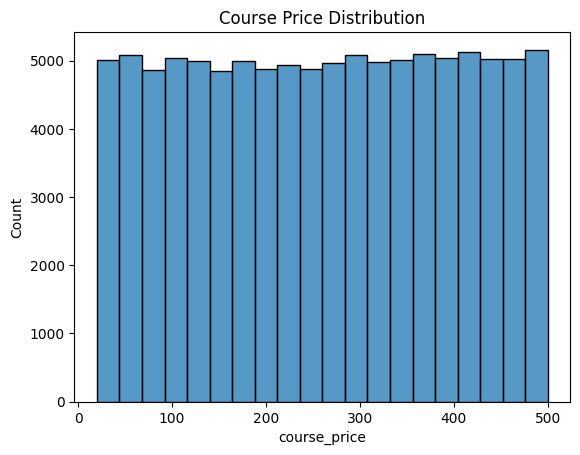

In [12]:
plt.figure()
sns.histplot(df['course_price'], bins=20)
plt.title("Course Price Distribution")
plt.show()

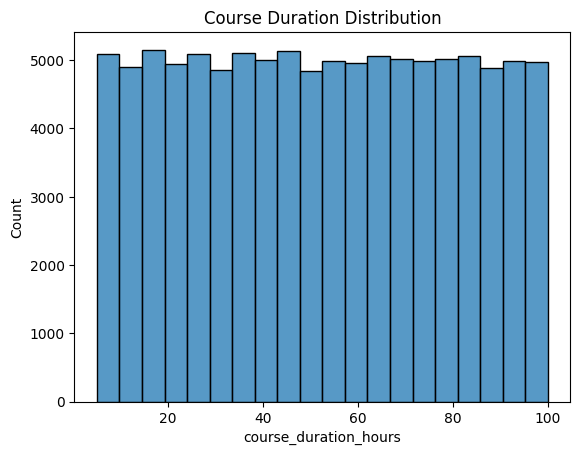

In [13]:
plt.figure()
sns.histplot(df['course_duration_hours'], bins=20)
plt.title("Course Duration Distribution")
plt.show()

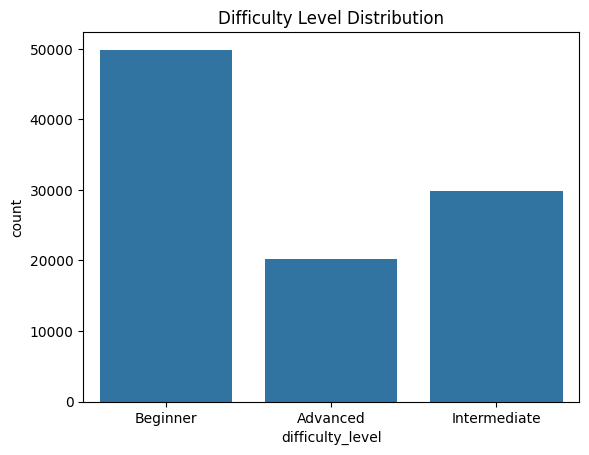

In [14]:
plt.figure()
sns.countplot(x='difficulty_level', data=df)
plt.title("Difficulty Level Distribution")
plt.show()

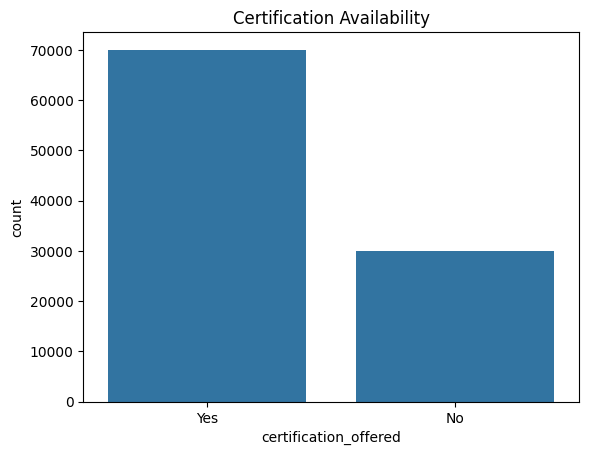

In [15]:
plt.figure()
sns.countplot(x='certification_offered', data=df)
plt.title("Certification Availability")
plt.show()

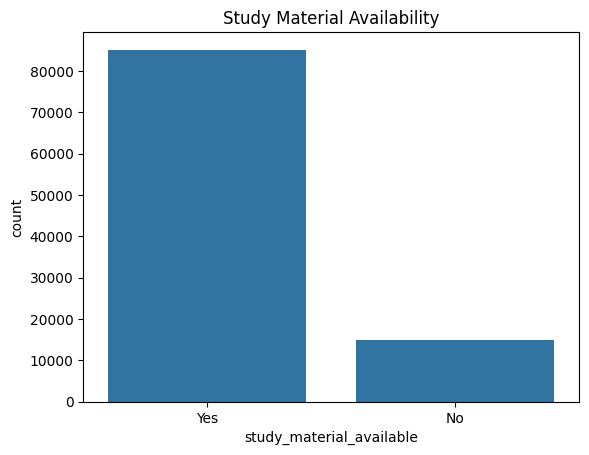

In [16]:
plt.figure()
sns.countplot(x='study_material_available', data=df)
plt.title("Study Material Availability")
plt.show()

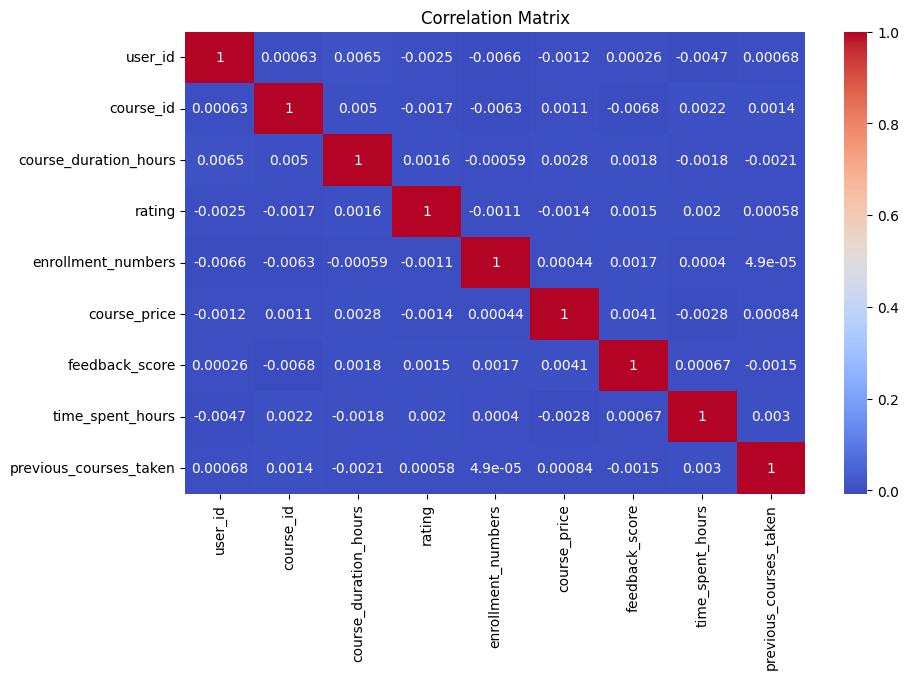

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


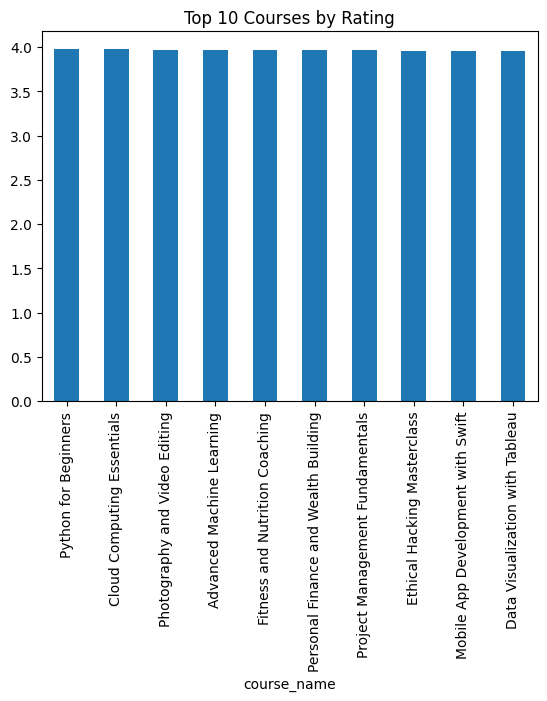

In [18]:
top_rated = df.groupby('course_name')['rating'].mean().sort_values(ascending=False).head(10)
top_rated.plot(kind='bar', title="Top 10 Courses by Rating")
plt.show()

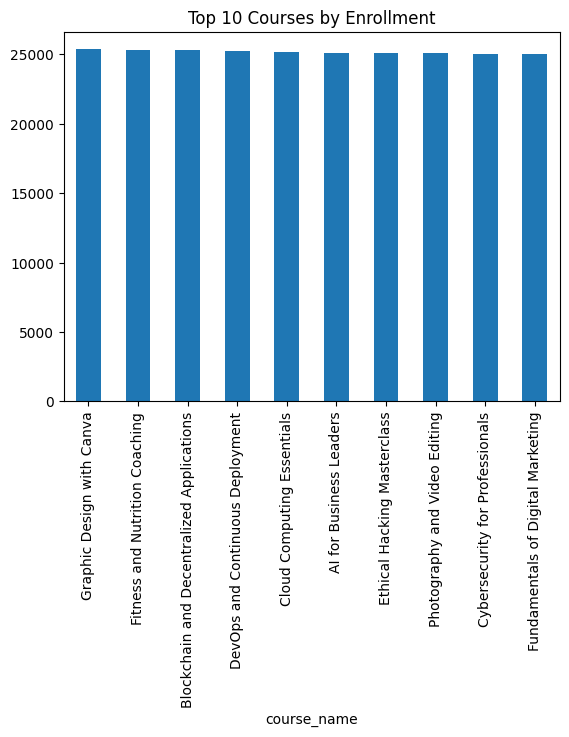

In [19]:
top_enroll = df.groupby('course_name')['enrollment_numbers'].mean().sort_values(ascending=False).head(10)
top_enroll.plot(kind='bar', title="Top 10 Courses by Enrollment")
plt.show()


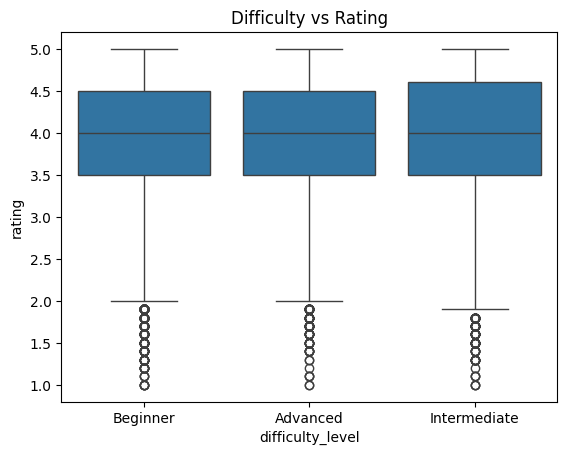

In [20]:
plt.figure()
sns.boxplot(x='difficulty_level', y='rating', data=df)
plt.title("Difficulty vs Rating")
plt.show()

In [21]:
def popularity_model(top_n=5):
    temp = df.groupby('course_id').agg({
        'rating':'mean',
        'enrollment_numbers':'mean'
    }).reset_index()

    scaler = MinMaxScaler()
    temp[['rating','enrollment_numbers']] = scaler.fit_transform(
        temp[['rating','enrollment_numbers']]
    )

    temp['score'] = 0.7*temp['rating'] + 0.3*temp['enrollment_numbers']

    top_courses = temp.sort_values('score', ascending=False).head(top_n)

    return df[df['course_id'].isin(top_courses['course_id'])][
        ['course_name','difficulty_level']
    ].drop_duplicates()

In [22]:
def rating_model(top_n=5):
    top = df.groupby('course_name')['rating'].mean().sort_values(
        ascending=False
    ).head(top_n)

    return top.reset_index()

In [23]:
def price_model(selected_course, top_n=5):
    topic = df[df['course_name']==selected_course]['topic'].iloc[0]

    topic_df = df[df['topic']==topic]

    return topic_df.sort_values(
        'course_price'
    ).head(top_n)[['course_name','course_price','difficulty_level']]

In [24]:
df['content_features'] = (
    df['course_name'] + " " +
    df['difficulty_level'] + " " +
    df['instructor']
)

tfidf = TfidfVectorizer(max_features=500)
tfidf_matrix = tfidf.fit_transform(df['content_features'])

content_model = NearestNeighbors(metric='cosine', algorithm='brute')
content_model.fit(tfidf_matrix)

def content_model_recommend(selected_course, top_n=5):

    idx = df[df['course_name']==selected_course].index[0]

    distances, indices = content_model.kneighbors(
        tfidf_matrix[idx],
        n_neighbors=top_n+1
    )

    rec_indices = indices.flatten()[1:]

    return df.iloc[rec_indices][
        ['course_name','difficulty_level']
    ].drop_duplicates()

In [25]:
user_item = df.pivot_table(
    index='user_id',
    columns='course_id',
    values='rating'
).fillna(0)

matrix = csr_matrix(user_item.values)

svd = TruncatedSVD(n_components=20, random_state=42)
latent_matrix = svd.fit_transform(matrix)

reconstructed = np.dot(latent_matrix, svd.components_)

predicted_ratings = pd.DataFrame(
    reconstructed,
    index=user_item.index,
    columns=user_item.columns
)

def collaborative_model(user_id, top_n=5):

    user_pred = predicted_ratings.loc[user_id]
    top_courses = user_pred.sort_values(
        ascending=False
    ).head(top_n).index

    return df[df['course_id'].isin(top_courses)][
        ['course_name','difficulty_level']
    ].drop_duplicates()


In [26]:
def recommend_courses(selected_course, top_n=10):

    selected_row = df[df["course_name"] == selected_course].iloc[0]

    selected_topic = selected_row["topic"]

    # find related courses
    related = df[df["topic"] == selected_topic]

    related = related[related["course_name"] != selected_course]

    if len(related) > 0:

        scaler = MinMaxScaler()

        related[['rating_norm','price_norm']] = scaler.fit_transform(
            related[['rating','course_price']]
        )

        related["price_score"] = 1 - related["price_norm"]

        related["final_score"] = (
            0.7 * related["rating_norm"] +
            0.3 * related["price_score"]
        )

        related = related.sort_values("final_score", ascending=False)

        return related.head(top_n)[[
            "course_id",
            "course_name",
            "difficulty_level",
            "rating",
            "course_price"
        ]], True


    # fallback
    top_courses = df[df["course_name"] != selected_course]

    top_courses = top_courses.sort_values("rating", ascending=False)

    return top_courses.head(top_n)[[
        "course_id",
        "course_name",
        "difficulty_level",
        "rating",
        "course_price"
    ]], False

In [27]:
actual = []
predicted = []

for row in df.itertuples():
    try:
        pred = predicted_ratings.loc[row.user_id, row.course_id]
        actual.append(row.rating)
        predicted.append(pred)
    except:
        continue

rmse = np.sqrt(mean_squared_error(actual, predicted))
print("Collaborative Model RMSE:", rmse)

Collaborative Model RMSE: 3.7864094443094363


In [32]:
print("Popularity Model:\n", popularity_model())

print("\nRating Model:\n", rating_model())

print("\nContent Model:\n", content_model_recommend(df['course_name'].iloc[0]))

print("\nCollaborative Model:\n", collaborative_model(df['user_id'].iloc[0]))

print("\nrecommend courses:\n", recommend_courses(df['course_name'].iloc[0]))

Popularity Model:
                               course_name difficulty_level
231   Stock Market and Trading Strategies         Beginner
351   Stock Market and Trading Strategies     Intermediate
568       Project Management Fundamentals     Intermediate
902   Stock Market and Trading Strategies         Advanced
937       Project Management Fundamentals         Beginner
1092            Graphic Design with Canva     Intermediate
1321      Cybersecurity for Professionals         Beginner
1556            Graphic Design with Canva         Advanced
2019      Project Management Fundamentals         Advanced
2079            Graphic Design with Canva         Beginner
2994      Cybersecurity for Professionals     Intermediate
3102      Cybersecurity for Professionals         Advanced

Rating Model:
                       course_name    rating
0            Python for Beginners  3.977652
1      Cloud Computing Essentials  3.974624
2   Photography and Video Editing  3.970811
3       Advanced Machi

In [34]:
def extract_topic(name):

    name = name.lower()

    if "python" in name:
        return "python"

    elif "machine learning" in name or "ai" in name:
        return "machine_learning"

    elif "data" in name or "tableau" in name:
        return "data_science"

    elif "devops" in name:
        return "devops"

    elif "cloud" in name:
        return "cloud"

    elif "blockchain" in name:
        return "blockchain"

    elif "cyber" in name or "security" in name or "ethical hacking" in name:
        return "cybersecurity"

    elif "marketing" in name:
        return "marketing"

    elif "finance" in name or "stock" in name or "trading" in name:
        return "finance"

    elif "design" in name or "canva" in name:
        return "design"

    elif "game" in name or "unity" in name:
        return "game_dev"

    else:
        return "general"

In [37]:
df["topic"] = df["course_name"].apply(extract_topic)
df["topic"].head()

,topic
0,python
1,cybersecurity
2,devops
3,general
4,cybersecurity


In [38]:
df_courses = df.drop_duplicates(subset=["course_name"]).copy()

df_courses = df_courses[
[
"course_id",
"course_name",
"topic",
"difficulty_level",
"rating",
"course_price"
]]

df_courses = df_courses.reset_index(drop=True)

import pickle

with open("courses_data.pkl", "wb") as f:
    pickle.dump(df_courses, f)